In [1]:
import json
from collections import defaultdict
import seaborn as sns
from tools.analysis_tools.analyze_logs import load_json_logs
import matplotlib.pyplot as plt
from tools.customize_tools.image_demo_config import image_demo_config
from tools.demo.image_demo_folder import get_all_files_with_suffix, main_args, get_all_subfolders, load_model

import os

/home/weiwang/anaconda3/envs/openmmlab/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def load_json_file(json_file):
    log_dict = {}
    with open(json_file) as log_file:
        for line in log_file:
            log = json.loads(line.strip())
            # the final step in json file is 0.
            if 'step' in log and log['step'] != 0:
                step = log['step']
                prev_step = step
            else:
                step = prev_step
            if step not in log_dict:
                log_dict[step] = defaultdict(list)
            for k, v in log.items():
                log_dict[step][k].append(v)
    return log_dict

def build_plot_index_list(log_dict, metric):
    epochs = list(log_dict.keys())
    plot_epochs = []
    plot_iters = []
    plot_values = []
    for epoch in epochs:
        epoch_logs = log_dict[epoch]
        if metric not in epoch_logs.keys():
            continue
        if metric in ['mIoU', 'mAcc', 'aAcc']:
            plot_epochs.append(epoch)
            plot_values.append(epoch_logs[metric][0])
        else:
            for idx in range(len(epoch_logs[metric])):
                plot_iters.append(epoch_logs['step'][idx])
                plot_values.append(epoch_logs[metric][idx])
    if metric in ['mIoU', 'mAcc', 'aAcc']:
        return plot_epochs, plot_values
    else:
        return plot_iters, plot_values
def customized_plot(x, y, curve_line_type='-', curve_line_thickness=1, curve_line_color='#2166ac',
                    marker_type='o', marker_color='#fee08b', marker_size=5,
                    x_tick_interval=5, y_tick_interval=5, 
                    x_range=None, y_range=[80, 100], 
                    axis_font_size=10, axis_font_name='DejaVu Sans', 
                    x_label='', y_label='', title=''):
    plt.figure(figsize=(10, 6))

    # Plotting the curve
    plt.plot(x, y, linestyle=curve_line_type, linewidth=curve_line_thickness, color=curve_line_color,
             marker=marker_type, markerfacecolor=marker_color, markersize=marker_size)

    # Customizing ticks
    plt.xticks(fontsize=axis_font_size, fontname=axis_font_name)
    plt.yticks(fontsize=axis_font_size, fontname=axis_font_name)

    # Setting tick intervals
    plt.gca().xaxis.set_major_locator(plt.MultipleLocator(x_tick_interval))
    plt.gca().yaxis.set_major_locator(plt.MultipleLocator(y_tick_interval))

    # Setting range for x and y axis if provided
    if x_range is not None:
        plt.xlim(x_range)
    if y_range is not None:
        plt.ylim(y_range)

    # Setting labels and title
    plt.xlabel(x_label, fontsize=axis_font_size, fontname=axis_font_name)
    plt.ylabel(y_label, fontsize=axis_font_size, fontname=axis_font_name)
    plt.title(title, fontsize=axis_font_size + 2, fontname=axis_font_name)

    # Show grid
    # plt.grid(True)
    plt.show()
    
def customized_plots(xs, ys, curve_line_types=['-', '--'], curve_line_thickness=1, curve_line_colors=['#2166ac', 'red'],
                    marker_types=['o', '^'], marker_colors=['#fee08b', 'white'], marker_size=5,
                    x_tick_interval=5, y_tick_interval=5, fig_size = (6, 12),
                    x_range=None, y_range=[80, 100], 
                    axis_font_size=10, axis_font_name='DejaVu Sans', 
                    legend_label=['mIoU', 'mAcc'], legend_font_size=12, legend_location='lower right',
                    x_label='', y_label='', title='', save_path=None, dpi=600):
    plt.figure(figsize=fig_size)
    for i in range(len(xs)):
        x, y, curve_line_type, curve_line_color, marker_type, marker_color = xs[i], ys[i], curve_line_types[i], curve_line_colors[i], marker_types[i], marker_colors[i]
        # Plotting the curve
        plt.plot(x, y, linestyle=curve_line_type, linewidth=curve_line_thickness, color=curve_line_color,
                marker=marker_type, markerfacecolor=marker_color, markersize=marker_size)

    # Customizing ticks
    plt.xticks(fontsize=axis_font_size, fontname=axis_font_name)
    plt.yticks(fontsize=axis_font_size, fontname=axis_font_name)

    # Setting tick intervals
    plt.gca().xaxis.set_major_locator(plt.MultipleLocator(x_tick_interval))
    plt.gca().yaxis.set_major_locator(plt.MultipleLocator(y_tick_interval))

    # Setting range for x and y axis if provided
    if x_range is not None:
        plt.xlim(x_range)
    if y_range is not None:
        plt.ylim(y_range)

    # Setting labels and title
    plt.xlabel(x_label, fontsize=axis_font_size, fontname=axis_font_name)
    plt.ylabel(y_label, fontsize=axis_font_size, fontname=axis_font_name)
    plt.title(title, fontsize=axis_font_size + 2, fontname=axis_font_name)
    if legend_label:
        plt.legend(legend_label, fontsize=legend_font_size, loc=legend_location)
    if save_path:
        plt.savefig(save_path, dpi=dpi)
    # Show grid
    # plt.grid(True)
    plt.show()



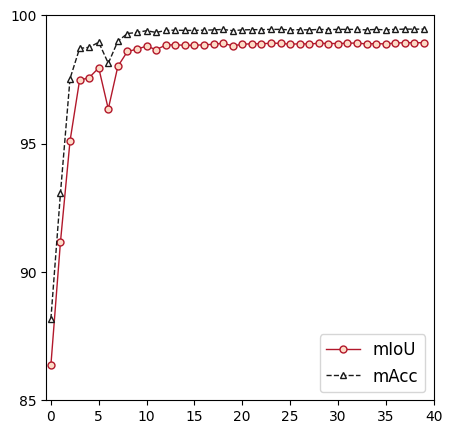

In [73]:
json_file = 'my_model_res/deeplabv3plus/20240603_225158/vis_data/20240603_225158.json'
log_dict = load_json_file(json_file)
metric, xs, ys = ['mIoU', 'mAcc'], [], []
plot_props = {
    'curve_line_types':['-', '--'], 
    'curve_line_thickness':1,
    'curve_line_colors':['#b2182b', '#1a1a1a'],
    'marker_types':['o', '^'], 
    'marker_colors':['#fddbc7', 'white'],
    'y_range':[85,100],
    'x_range':[-0.5,40],
    'fig_size': [5, 5],
    'save_path' : './curve.jpg'
}
for m in metric:
    plot_x, plot_y = build_plot_index_list(log_dict, m)
    
    plot_x = [0] + [i / 2000 for i in plot_x]
    plot_y = [plot_y[0] * 0.9] + plot_y
    plot_y[1] = plot_y[1] * 0.95
    xs.append(plot_x[:40])
    ys.append(plot_y[:40])
customized_plots(xs, ys, **plot_props)


In [2]:
img_folder = '/media/weiwang/SSD1/New_Test/2012/'
config_file = './my_model/deeplabv3plus/deeplabv3plus_r50-d8_4xb4-20k_voc12aug-512x512.py'
checkpoint_file = '/home/weiwang/ResearchProjects/mmsegmentation/my_model_res/deeplabv3plus/iter_100000.pth'
output_parent_folder = '/media/weiwang/SSD1/New_Test_Res_V2/2012/'
img_suffix = 'png'
sub_folders = get_all_subfolders(img_folder)
count = 0
for s in sub_folders:
    if get_all_files_with_suffix(s, img_suffix):
        
        input_folder = s + '/'
        output_folder = output_parent_folder + '/' + s.split('/')[-2] + '/' + s.split('/')[-1] + '/'
        args = image_demo_config(input_folder, config_file, checkpoint_file, output_folder, img_suffix = img_suffix)
        if count == 0:
            
            model = load_model(args)
        main_args(args, model = model)
        count += 1

/mnt/ssd1/simple_mmseg/mmseg/models/decode_heads/decode_head.py:120: UserWarning: For binary segmentation, we suggest using`out_channels = 1` to define the outputchannels of segmentor, and use `threshold`to convert `seg_logits` into a predictionapplying a threshold
  warnings.warn('For binary segmentation, we suggest using'
/mnt/ssd1/simple_mmseg/mmseg/models/losses/cross_entropy_loss.py:250: UserWarning: Default ``avg_non_ignore`` is False, if you would like to ignore the certain label and average loss over non-ignore labels, which is the same with PyTorch official cross_entropy, set ``avg_non_ignore=True``.
  warnings.warn(


Loads checkpoint by local backend from path: /home/weiwang/ResearchProjects/mmsegmentation/my_model_res/deeplabv3plus/iter_100000.pth
06/12 19:35:40 - mmengine - WARNING - `Visualizer` backend is not initialized because save_dir is None.


In [4]:
img_folder = '/media/weiwang/SSD1/New_Test'
config_file = '/home/weiwang/ResearchProjects/mmsegmentation/my_model/deeplabv3plus/deeplabv3plus_r50-d8_4xb4-20k_voc12aug-512x512.py'
checkpoint_file = '/mnt/ssd1/mmseg_backup/model_res_wo_05-07/iter_100000.pth'
output_parent_folder = '/media/weiwang/SSD1/New_Test_Res_wo_05-07/'
img_suffix = 'png'
sub_folders = get_all_subfolders(img_folder)
for s in sub_folders:
    if get_all_files_with_suffix(s, img_suffix):
        input_folder = s + '/'
        output_folder = output_parent_folder + '/' + s.split('/')[-2] + '/' + s.split('/')[-1] + '/'
        args = image_demo_config(input_folder, config_file, checkpoint_file, output_folder, img_suffix = img_suffix)
        main_args(args)

Loads checkpoint by local backend from path: /mnt/ssd1/mmseg_backup/model_res_wo_05-07/iter_100000.pth
Loads checkpoint by local backend from path: /mnt/ssd1/mmseg_backup/model_res_wo_05-07/iter_100000.pth
Loads checkpoint by local backend from path: /mnt/ssd1/mmseg_backup/model_res_wo_05-07/iter_100000.pth
Loads checkpoint by local backend from path: /mnt/ssd1/mmseg_backup/model_res_wo_05-07/iter_100000.pth
Loads checkpoint by local backend from path: /mnt/ssd1/mmseg_backup/model_res_wo_05-07/iter_100000.pth
Loads checkpoint by local backend from path: /mnt/ssd1/mmseg_backup/model_res_wo_05-07/iter_100000.pth
Loads checkpoint by local backend from path: /mnt/ssd1/mmseg_backup/model_res_wo_05-07/iter_100000.pth
Loads checkpoint by local backend from path: /mnt/ssd1/mmseg_backup/model_res_wo_05-07/iter_100000.pth
Loads checkpoint by local backend from path: /mnt/ssd1/mmseg_backup/model_res_wo_05-07/iter_100000.pth
Loads checkpoint by local backend from path: /mnt/ssd1/mmseg_backup/model